# Fractals and the Sierpinski gasket

A **fractal** is a geometric object with structure on many scales. Many familiar fractals exhibit **self-similarity**: smaller parts resemble the whole, exactly or statistically. Natural examples such as branching trees and coastlines show approximate fractal patterns over a limited range of scales; mathematical fractals can have detail at arbitrarily small scales.

The **Sierpinski gasket** (also called the Sierpinski triangle) is a classic exactly self-similar fractal. One geometric construction starts with a filled triangle, joins the midpoints of its sides, and removes the central triangle. Repeating this removal in each of the three remaining triangles produces progressively finer holes. The ideal gasket is the limiting set after infinitely many repetitions; this notebook draws a finite approximation.

Each stage contains three copies of the whole, each scaled by a factor of $1/2$. Its similarity dimension is therefore

$$3(1/2)^D=1, \qquad D=\frac{\log 3}{\log 2}\approx 1.585.$$

This dimension lies between that of a line ($1$) and a filled region ($2$). In the removal construction, the remaining area is multiplied by $3/4$ at each stage, so the ideal gasket has zero area despite its intricate structure.

## A random construction: the chaos game

We will generate the same pattern using a simple repeated rule:

1. Choose three non-collinear vertices to define a triangle.
2. Choose an initial point in the plane.
3. Select one of the three vertices at random, with equal probability.
4. Move halfway from the current point toward that vertex.
5. Repeat the selection and midpoint update thousands of times, plotting the visited points.

Although the vertex choices are random, the accumulated points reveal an organized fractal. The cells below implement this procedure using `State` for coordinates, `System` for the triangle, `TimeSeries` for stored coordinates, and Matplotlib for plotting. These first three containers come from `modsim`.


In [1]:
import numpy as np

# import functions from modsim

from modsim import *

import random
import matplotlib.pyplot as plt

## 1. Choose the triangle vertices

Each vertex is a `State` with `x` and `y` coordinates. The code randomly places one vertex near the lower right, one near the top, and one near the lower left, then collects them in the `triangle` system.

The triangle need not be equilateral: any non-degenerate triangle gives an affine version of the Sierpinski gasket. Randomizing the vertices changes the overall shape and orientation, while the halfway rule preserves the same self-similar construction. The calls with endpoints `(-5, -10)` still sample coordinates between those two values.


In [2]:
# create a state object to contain the position of a point in 2D

# point 1 of triangle
xr = random.uniform(5,10)
yr = random.uniform(-5,-10)
point1 = State(x=xr, y=yr)

# point 2 of triangle
xr = random.uniform(-2.5,2.5)
yr = random.uniform(5,10)
point2 = State(x=xr, y=yr)

# point 3 of triangle
xr = random.uniform(-5,-10)
yr = random.uniform(-5,-10)
point3 = State(x=xr, y=yr)

# create a system object to contain the system parameters
triangle = System(point1=point1, point2=point2, point3=point3)

## 2. Apply the midpoint rule

`new_point` selects a vertex using `random.randint(1, 3)`, so each vertex has probability $1/3$. If the current point is $\mathbf{p}_k=(x_k,y_k)$ and the chosen vertex is $\mathbf{v}_j$, the update is

$$\mathbf{p}_{k+1}=\frac{\mathbf{p}_k+\mathbf{v}_j}{2}.$$

In coordinates, this means averaging the two x values and the two y values. Each of the three possible maps shrinks distances by $1/2$ toward its vertex. Together, these maps take the full triangle into its three corner triangles, leaving the central triangle empty. Repeated application creates smaller copies of these gaps. This collection of contraction maps is called an **iterated function system**.


In [3]:
def new_point(triangle, point):
    """Computes a new point, based on the triangle and the point.
    
    triangle: System object with three points
    point: State object with x and y
    
    returns: State object with new x and y
    """
    
    # choose one of the three points at random
    i = random.randint(1,3)
    if i == 1:
        p = triangle.point1
    elif i == 2:
        p = triangle.point2
    else:
        p = triangle.point3
        
    # compute the midpoint between the point and the chosen point
    x = (point.x + p.x) / 2
    y = (point.y + p.y) / 2
    
    # make a new point with the midpoint
    return State(x=x, y=y)

## 3. Repeat the rule and store the points

`run_simulation` maintains separate `TimeSeries` objects for the x and y coordinates. Each iteration records the current point, then calls `new_point` to advance it. The function returns the pair `(resultsX, resultsY)`.

Because storage happens **before** the update, `n` iterations store `n` points: the initial point and the next `n - 1` points. The point produced by the final update is not stored. The series indices count iterations; they do not represent physical time in this geometric model.

The contractions reduce the influence of the starting point by a factor of $1/2$ per step. Even a starting point outside the triangle approaches the gasket. A few early points may lie away from the visible pattern; a common refinement is to discard a short initial **burn-in** before storing points. This implementation keeps those initial points.


In [4]:
def run_simulation(triangle, point, n):
    """Computes a new point, based on the triangle and the point.
    
    triangle: System object with three points
    point: State object with x and y
    n: number of iterations
    
    returns: TimeSeries
    """
    
    #print("Starting point = ",point)
    #print("Triangle = ",triangle)
    #print("Number of iterations = ",n)
    # make a TimeSeries to store the results
    resultsX = TimeSeries()
    resultsY = TimeSeries()
    
    # run n times and store the results
    for i in range(n):
        resultsX[i] = point.x
        resultsY[i] = point.y
        point = new_point(triangle, point)
        #print(point)
    
    #print("Final point = ",point)

    return resultsX, resultsY

## 4. Define the plotting function

`plot_results` pairs the stored x and y coordinates and draws blue circular markers (`'bo'`). It displays the visited locations without connecting them by lines. The gasket becomes visible through the spatial distribution of these points, rather than through the order in which they were visited.


In [5]:
def plot_results(resultsX, resultsY):
    """Plot the results.
    
    results: TimeSeries
    """
    
    plt.plot(resultsX, resultsY, 'bo', label='path')

## 5. Generate a finite sample

The initial point is sampled from the square with x and y coordinates between -10 and 10. The simulation then runs for **10,000 iterations**. Increasing this number generally fills in more detail, while a smaller sample makes the pattern harder to recognize.

Re-running the random vertex or simulation cells produces different samples. To reproduce a particular run, one could call `random.seed(...)` before choosing both the vertices and the initial point. The code here intentionally leaves the random generator unseeded.


In [6]:
# create a state object to contain the position of a point in 2D

xr = random.uniform(-10,10)
yr = random.uniform(-10,10)
point = State(x=xr, y=yr)

#print ("Triangle = ",triangle)
#print ("Starting point = ",point)

resultsX, resultsY = run_simulation(triangle, point, 10000)


## 6. Display and interpret the gasket

The figure plots the stored sample with both coordinate ranges fixed at -10 to 10. Look for the large central triangular gap and smaller gaps repeated inside the three corner regions. These repeated structures are the visual signature of self-similarity.

The plot is a finite sample drawn with markers of nonzero size. It cannot show infinitely fine detail, and marker overlap can obscure the smallest gaps. The early points retained by this simulation may also appear outside the main pattern.

**Explore:** How does the pattern change if you increase or decrease the iteration count? Does changing the starting point alter the overall gasket? Why should moving halfway toward a vertex produce the same repeated triangular gaps as the geometric removal construction?


Text(0, 0.5, 'y')

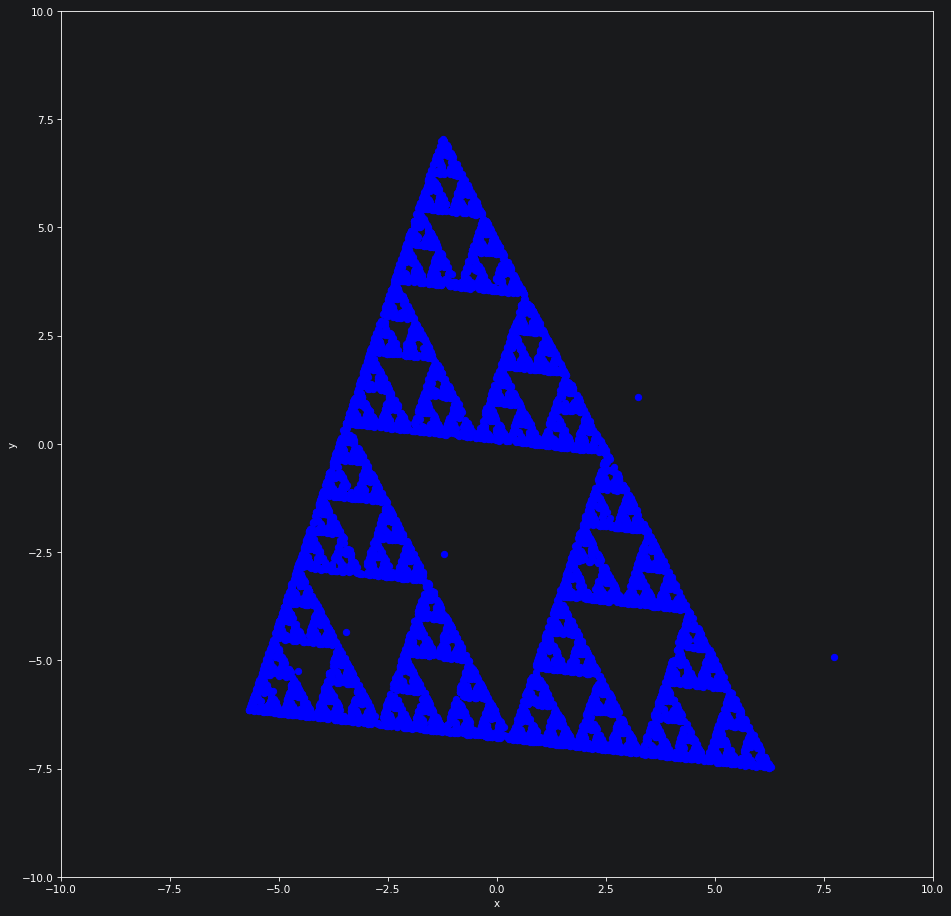

In [7]:
fig = plt.figure(figsize=(15,15))
plot_results(resultsX, resultsY)
plt.xlim(-10, 10)
plt.ylim(-10, 10)
plt.xlabel('x')
plt.ylabel('y')